Name: Sat Naing Tun, ID: st125333

## Exercise 1

In [1]:
import torch
import torch.nn as nn


class VanillaGenerator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 784),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)



class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


In [2]:
import torch
import torch.nn as nn

class DCGANGenerator(nn.Module):
    def __init__(self, noise_dim=100, ngf=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(noise_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z.view(z.size(0), z.size(1), 1, 1))


In [3]:
class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(ndf * 4 * 4 * 4, 1),  # adjust dims depending on input size
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)  # shape [B, 1]


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def get_mnist(batch=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    train = datasets.MNIST("data", train=True, download=True, transform=transform)
    return DataLoader(train, batch_size=batch, shuffle=True)

def get_cifar(batch=128):
    transform = transforms.Compose([
        transforms.Resize(32),
        transforms.CenterCrop(32),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    train = datasets.CIFAR10("data", train=True, download=True, transform=transform)
    return DataLoader(train, batch_size=batch, shuffle=True)


In [5]:
def train_one_epoch(generator, discriminator, loader, g_opt, d_opt, criterion, epoch, device, noise_dim=100):
    generator.train()
    discriminator.train()

    g_loss_epoch = 0
    d_loss_epoch = 0

    for real_imgs, _ in loader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # -----------------------
        # 1. Train Discriminator
        # -----------------------
        noise = torch.randn(batch_size, noise_dim, device=device)
        fake_imgs = generator(noise).detach()

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        d_real = discriminator(real_imgs)
        d_fake = discriminator(fake_imgs)

        d_loss_real = criterion(d_real, real_labels)
        d_loss_fake = criterion(d_fake, fake_labels)
        d_loss = d_loss_real + d_loss_fake

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # -----------------------
        # 2. Train Generator
        # -----------------------
        noise = torch.randn(batch_size, noise_dim, device=device)
        fake_imgs = generator(noise)

        g_loss = criterion(discriminator(fake_imgs), real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    return g_loss_epoch / len(loader), d_loss_epoch / len(loader)


In [6]:
def validate_one_epoch(generator, discriminator, loader, criterion, device, noise_dim=100):
    generator.eval()
    discriminator.eval()

    g_loss_epoch = 0
    d_loss_epoch = 0

    with torch.no_grad():
        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(device)
            batch = real_imgs.size(0)

            noise = torch.randn(batch, noise_dim, device=device)
            fake_imgs = generator(noise)

            real_labels = torch.ones(batch,1,device=device)
            fake_labels = torch.zeros(batch,1,device=device)

            d_real = discriminator(real_imgs)
            d_fake = discriminator(fake_imgs)

            d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)
            g_loss = criterion(d_fake, real_labels)

            g_loss_epoch += g_loss.item()
            d_loss_epoch += d_loss.item()

    return g_loss_epoch/len(loader), d_loss_epoch/len(loader)


In [7]:
def train_gan(generator, discriminator, loader, epochs, noise_dim, device):
    criterion = nn.BCELoss()
    g_opt = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    d_opt = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

    train_g_losses, train_d_losses = [], []
    val_g_losses, val_d_losses = [], []

    for epoch in range(1, epochs+1):
        g_train, d_train = train_one_epoch(
            generator, discriminator, loader,
            g_opt, d_opt, criterion, epoch, device,
            noise_dim=noise_dim
        )

        g_val, d_val = validate_one_epoch(
            generator, discriminator, loader,
            criterion, device, noise_dim=noise_dim
        )

        train_g_losses.append(g_train)
        train_d_losses.append(d_train)
        val_g_losses.append(g_val)
        val_d_losses.append(d_val)

        print(f"[Epoch {epoch}/{epochs}] G_train={g_train:.4f} D_train={d_train:.4f} | G_val={g_val:.4f} D_val={d_val:.4f}")

    return train_g_losses, train_d_losses, val_g_losses, val_d_losses


In [8]:
import matplotlib.pyplot as plt

def plot_gan_losses(g_train, d_train, g_val, d_val, title="GAN Loss"):
    plt.figure(figsize=(10,6))
    plt.plot(g_train, label="G Train")
    plt.plot(d_train, label="D Train")
    plt.plot(g_val, '--', label="G Val")
    plt.plot(d_val, '--', label="D Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

✅ Using device: cuda


In [10]:
# device = "cuda"

loader = get_mnist(batch=128)
G = VanillaGenerator().to(device)
D = VanillaDiscriminator().to(device)

g_tr, d_tr, g_val, d_val = train_gan(G, D, loader,
                                     epochs=50,
                                     noise_dim=100,
                                     device=device)




100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.29MB/s]


[Epoch 1/50] G_train=1.5415 D_train=0.8477 | G_val=2.5747 D_val=1.5991
[Epoch 2/50] G_train=2.3504 D_train=0.6795 | G_val=0.5492 D_val=1.0270
[Epoch 3/50] G_train=2.5753 D_train=0.6296 | G_val=1.7324 D_val=0.3650
[Epoch 4/50] G_train=2.4673 D_train=0.6683 | G_val=1.3039 D_val=0.6065
[Epoch 5/50] G_train=2.3866 D_train=0.6181 | G_val=1.3717 D_val=0.4954
[Epoch 6/50] G_train=2.5838 D_train=0.5758 | G_val=1.9456 D_val=0.5170
[Epoch 7/50] G_train=2.8963 D_train=0.5548 | G_val=2.6192 D_val=0.2891
[Epoch 8/50] G_train=2.9977 D_train=0.5957 | G_val=1.7312 D_val=0.4884
[Epoch 9/50] G_train=2.6873 D_train=0.5869 | G_val=1.5030 D_val=0.4563
[Epoch 10/50] G_train=2.6825 D_train=0.5781 | G_val=2.5224 D_val=0.5121
[Epoch 11/50] G_train=2.6003 D_train=0.5899 | G_val=1.2291 D_val=0.6148
[Epoch 12/50] G_train=2.3958 D_train=0.6061 | G_val=2.9169 D_val=0.5432
[Epoch 13/50] G_train=2.3510 D_train=0.6162 | G_val=1.8428 D_val=0.5681
[Epoch 14/50] G_train=2.3010 D_train=0.6641 | G_val=0.8969 D_val=0.8374
[

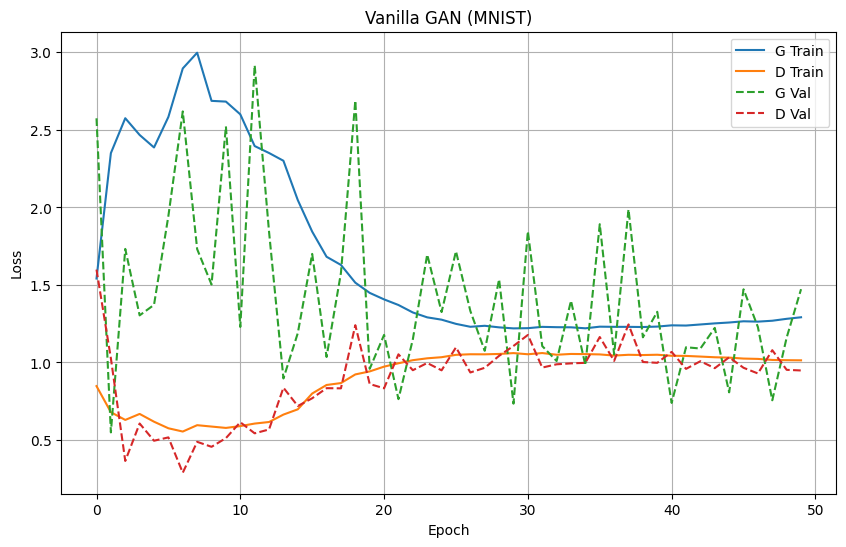

In [11]:
plot_gan_losses(g_tr, d_tr, g_val, d_val, title="Vanilla GAN (MNIST)")

In [12]:

device = "cuda"

loader = get_cifar(batch=128)
G = DCGANGenerator().to(device)
D = DCGANDiscriminator().to(device)

g_tr, d_tr, g_val, d_val = train_gan(G, D, loader,
                                     epochs=100,
                                     noise_dim=100,
                                     device=device)




100%|██████████| 170M/170M [00:14<00:00, 11.8MB/s]


[Epoch 1/100] G_train=4.7127 D_train=0.3673 | G_val=2.0086 D_val=0.9475
[Epoch 2/100] G_train=3.7223 D_train=0.4553 | G_val=2.3815 D_val=1.0401
[Epoch 3/100] G_train=2.9081 D_train=0.5869 | G_val=1.2700 D_val=1.1776
[Epoch 4/100] G_train=2.7574 D_train=0.5556 | G_val=1.0935 D_val=0.9641
[Epoch 5/100] G_train=2.5741 D_train=0.6140 | G_val=2.0406 D_val=1.2636
[Epoch 6/100] G_train=2.6738 D_train=0.5940 | G_val=0.9474 D_val=1.0552
[Epoch 7/100] G_train=2.7146 D_train=0.5542 | G_val=1.3630 D_val=0.8687
[Epoch 8/100] G_train=2.7165 D_train=0.5313 | G_val=1.7796 D_val=0.8452
[Epoch 9/100] G_train=2.6512 D_train=0.5187 | G_val=2.9255 D_val=1.5539
[Epoch 10/100] G_train=2.7477 D_train=0.4921 | G_val=1.6778 D_val=0.7710
[Epoch 11/100] G_train=2.7087 D_train=0.5574 | G_val=1.6050 D_val=0.8293
[Epoch 12/100] G_train=2.7641 D_train=0.5125 | G_val=1.7888 D_val=1.0464
[Epoch 13/100] G_train=2.7108 D_train=0.4852 | G_val=2.4543 D_val=1.2280
[Epoch 14/100] G_train=2.7515 D_train=0.4916 | G_val=1.5318 

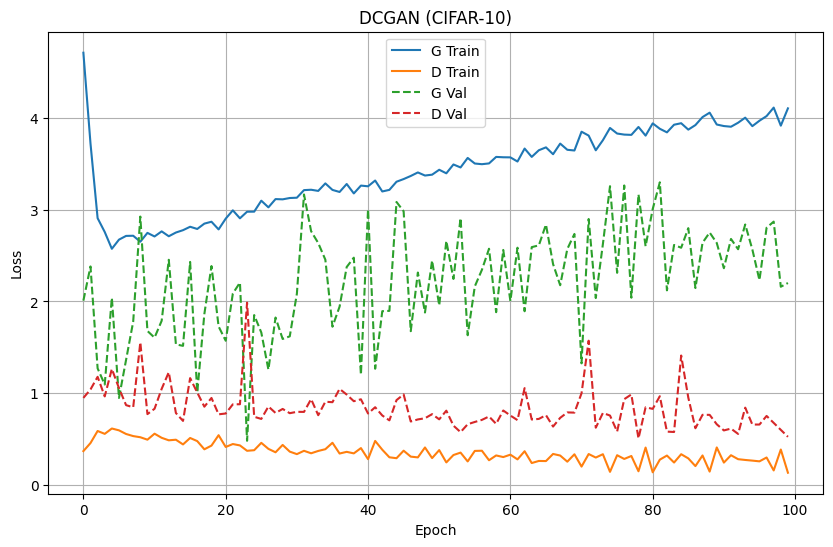

In [13]:
plot_gan_losses(g_tr, d_tr, g_val, d_val, title="DCGAN (CIFAR-10)")

## Exercise 2

In [14]:
import os
import requests
from tqdm import tqdm

def download_big_file(dest_path,url):
    # Ensure destination directory exists
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)

    if os.path.exists(dest_path):
        print(f"✅ Skipping {os.path.basename(dest_path)} (already exists)")
        return

    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))

    with open(dest_path, 'wb') as file, tqdm(
        desc=os.path.basename(dest_path),
        total=total,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = file.write(data)
            bar.update(size)

In [15]:
import os
import zipfile
from tqdm import tqdm

def unzip_folder(zip_path, extract_to, sub_dir="train"):
    expected_path = os.path.join(extract_to, sub_dir)
    if os.path.exists(expected_path) and any(os.scandir(expected_path)):
        print(f"⚠️ Skipping extraction: {expected_path} already populated")
        return

    print(f"📦 Extracting {os.path.basename(zip_path)} → {extract_to}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for member in tqdm(zip_ref.infolist(), desc="Extracting", unit="file"):
            zip_ref.extract(member, extract_to)

In [16]:
# raw_zip_dir = "DLCV_Lab_Dataset/raw_zips/human-faces.zip"
# source_url = "https://www.kaggle.com/api/v1/datasets/download/ashwingupta3012/human-faces"
# download_big_file(raw_zip_dir, source_url)

In [17]:
# zip_path = "DLCV_Lab_Dataset/raw_zips/human-faces.zip"
# extract_path = "DLCV_Lab_Dataset"
# unzip_folder(zip_path, extract_path)

In [18]:
raw_zip_dir = "DLCV_Lab_Dataset/raw_zips/human-faces-dataset.zip"
source_url = "https://www.kaggle.com/api/v1/datasets/download/kaustubhdhote/human-faces-dataset"
download_big_file(raw_zip_dir, source_url)

human-faces-dataset.zip: 100%|██████████| 114M/114M [00:06<00:00, 19.1MB/s]


In [19]:
zip_path = "DLCV_Lab_Dataset/raw_zips/human-faces-dataset.zip"
extract_path = "DLCV_Lab_Dataset"
unzip_folder(zip_path, extract_path)

📦 Extracting human-faces-dataset.zip → DLCV_Lab_Dataset


Extracting: 100%|██████████| 9630/9630 [00:01<00:00, 5982.28file/s]


In [20]:
from PIL import Image

image_path='/content/DLCV_Lab_Dataset/Human Faces Dataset/Real Images/000001.jpg'
img = Image.open(image_path)



width, height = img.size
print(f"Width: {width}, Height: {height}")

Width: 178, Height: 218


In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import os


In [22]:
from PIL import Image
import torchvision.transforms as T

class CustomImageFolder(torch.utils.data.Dataset):
    def __init__(self, root, target_size=(160, 160)):
        self.root = root
        self.paths = [
            os.path.join(root, f)
            for f in os.listdir(root)
            if f.lower().endswith(("jpg", "jpeg", "png"))
        ]

        self.transform = T.Compose([
            T.Resize(target_size),
            T.CenterCrop(target_size),
            T.ToTensor(),
            T.Normalize([0.5]*3, [0.5]*3),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)


In [23]:
class UniversalGenerator(nn.Module):
    def __init__(self, latent_dim=256, base_channels=64, target_size=(160,160), im_chan=3):
        super().__init__()
        H, W = target_size
        assert H % 16 == 0 and W % 16 == 0, "Target size must be divisible by 16."

        layers = []
        c = base_channels * 8

        # Start from 4×4
        layers.append(nn.Sequential(
            nn.ConvTranspose2d(latent_dim, c, 4, 1, 0),
            nn.BatchNorm2d(c),
            nn.ReLU(True)
        ))

        out_h, out_w = 4, 4

        # Upsample dynamically until reaching target size
        while out_h < H or out_w < W:
            layers.append(nn.Sequential(
                nn.ConvTranspose2d(c, c // 2, 4, 2, 1),
                nn.BatchNorm2d(c // 2),
                nn.ReLU(True)
            ))
            c //= 2
            out_h *= 2
            out_w *= 2

        layers.append(nn.ConvTranspose2d(c, im_chan, 3, 1, 1))
        layers.append(nn.Tanh())

        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z.view(z.size(0), z.size(1), 1, 1))


In [24]:
class UniversalCritic(nn.Module):
    def __init__(self, im_chan=3, base_channels=64):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 4, 2, 1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True)
            )

        self.net = nn.Sequential(
            nn.Conv2d(im_chan, base_channels, 4, 2, 1),
            nn.LeakyReLU(0.2, True),

            block(base_channels, base_channels*2),
            block(base_channels*2, base_channels*4),
            block(base_channels*4, base_channels*8),

            nn.Conv2d(base_channels*8, 1, 4, 1, 0),
            nn.Flatten(),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


In [25]:
def generator_loss(fake_pred):
    return F.binary_cross_entropy(fake_pred, torch.ones_like(fake_pred))

def discriminator_loss(real_pred, fake_pred):
    real_loss = F.binary_cross_entropy(real_pred, torch.ones_like(real_pred))
    fake_loss = F.binary_cross_entropy(fake_pred, torch.zeros_like(fake_pred))
    return 0.5 * (real_loss + fake_loss)


In [26]:
def train_one_epoch(G, D, loader, optim_G, optim_D, device, latent_dim=256):
    G.train(); D.train()
    lossG, lossD = 0, 0

    for real in tqdm(loader, desc="Training", leave=False):
        real = real.to(device)
        bs = real.size(0)


        z = torch.randn(bs, latent_dim, device=device)
        fake = G(z).detach()

        optim_D.zero_grad()
        loss_d = discriminator_loss(D(real), D(fake))
        loss_d.backward()
        optim_D.step()


        z = torch.randn(bs, latent_dim, device=device)
        fake = G(z)

        optim_G.zero_grad()
        loss_g = generator_loss(D(fake))
        loss_g.backward()
        optim_G.step()

        lossG += loss_g.item()
        lossD += loss_d.item()

    return lossD/len(loader), lossG/len(loader)


In [27]:
import warnings
from PIL import Image


warnings.filterwarnings("ignore", category=UserWarning, module="PIL.Image")

latent_dim = 256
target_size = (128,128)
batch_size = 16
epochs = 50

data_path='/content/DLCV_Lab_Dataset/Human Faces Dataset/Real Images'

dataset = CustomImageFolder(root=data_path, target_size=(128,128))
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# G = UniversalGenerator(latent_dim=latent_dim, target_size=target_size).to(device)
G = UniversalGenerator(latent_dim=256, target_size=target_size).to(device)

D = UniversalCritic().to(device)

optim_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optim_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

history_G = []
history_D = []


for epoch in range(1, epochs + 1):
    d, g = train_one_epoch(G, D, loader, optim_G, optim_D, device, latent_dim)
    history_D.append(d)
    history_G.append(g)

    print(f"Epoch {epoch:03d} | D Loss: {d:.4f} | G Loss: {g:.4f}")


Epoch 001 | D Loss: 0.1163 | G Loss: 5.8133


Epoch 002 | D Loss: 0.3198 | G Loss: 3.6828


Epoch 003 | D Loss: 0.2583 | G Loss: 4.1174


Epoch 004 | D Loss: 0.2545 | G Loss: 4.0936


Epoch 005 | D Loss: 0.2940 | G Loss: 3.6813


...

Epoch 046 | D Loss: 0.1744 | G Loss: 5.5153


Epoch 047 | D Loss: 0.0800 | G Loss: 5.0253


Epoch 048 | D Loss: 0.0890 | G Loss: 5.3890


Epoch 049 | D Loss: 0.0715 | G Loss: 5.7694


Epoch 050 | D Loss: 0.1159 | G Loss: 5.9513


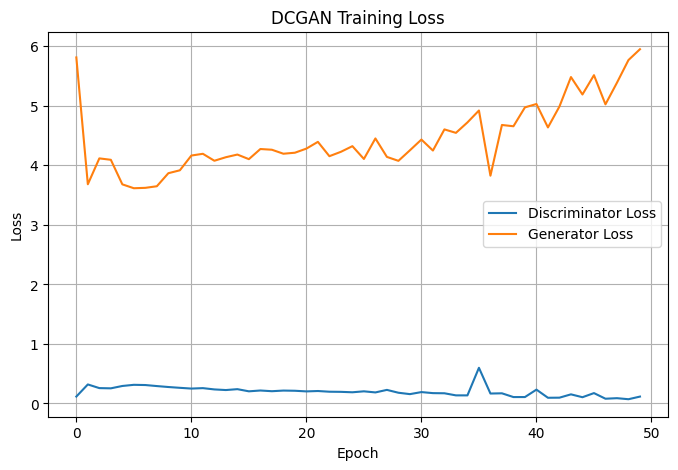

In [28]:
plt.figure(figsize=(8,5))
plt.plot(history_D, label="Discriminator Loss")
plt.plot(history_G, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Loss")
plt.legend()
plt.grid(True)
plt.show()


In [29]:
def denorm(x):
    return (x + 1) / 2


In [30]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

@torch.no_grad()
def generate_new_faces(G, num_images=16, latent_dim=256, device="cuda", save_path=None):

    G.eval()

    # Sample new latent vectors → these produce NEW synthetic faces
    z = torch.randn(num_images, latent_dim, device=device)

    fake_imgs = G(z)

    # Convert to [0,1] for visualization
    fake_imgs = denorm(fake_imgs)


    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.title("Generated New Synthetic Faces")
    plt.imshow(
        vutils.make_grid(fake_imgs.cpu(), nrow=4).permute(1, 2, 0)
    )
    plt.show()


    if save_path:
        vutils.save_image(fake_imgs, save_path, nrow=4)

    return fake_imgs


In [31]:
@torch.no_grad()
def generate_new_face(G, latent_dim=256, device="cuda"):

    G.eval()

    # Sample one latent vector
    z = torch.randn(1, latent_dim, device=device)


    fake = G(z)                     # shape: (1, 3, H, W)
    fake = denorm(fake)[0]          # shape: (3, H, W)


    img = fake.cpu().permute(1, 2, 0).numpy()  # (H, W, 3)


    img = img.clip(0, 1)


    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Generated Synthetic Face")
    plt.show()

    return img

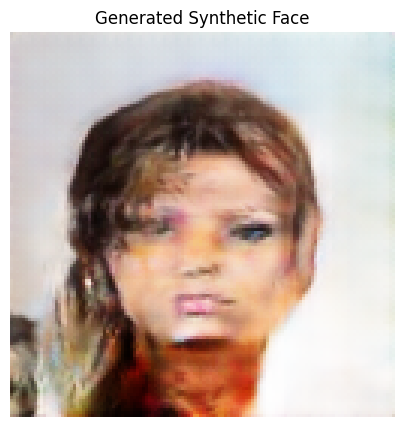

In [32]:
img = generate_new_face(G, latent_dim=256, device=device)
